# EEG Data and Linear Dynamic System Modeling



## **Seizure Clustering with EEG Data**

Authors: Erin Shappell, Ben Shealy

In this notebook we demonstrate how to use electroencephalogram (EEG) data to cluster seizures in epileptic and neurotypical patients. This work contains the code used for Erin Shappell's Honors Thesis submitted in Spring 2020.

In particular we draw from the EEG datasets:

- [CHB-MIT Scalp EEG Database](https://github.com/sereneHe/MIP-IF-4JointProblem/blob/main/Database/EEG/eeg_seizure_prediction.ipynb)

## **Mapping EEG Data to LDS**
*   EEG Data Shape: (119, 12,800, 23)

*   The Linear Dynamic System (LDS) is represented as:

$$
\mathbf{x}_s^c (t+1) = \mathbf{A} \mathbf{x}_s^c (t) + \mathbf{B} \mathbf{u}_s^c (t)
$$

$$
\mathbf{y}_s^c (t) = \mathbf{C} \mathbf{x}_s^c (t) + \mathbf{D} \mathbf{u}_s^c (t)
$$
where

  | **LDS Variable**      | **EEG Correspondence**                  |
  |----------------------|----------------------------------|
  | **s = 1, $\dots$, 119** | EEG **trials** |
  | **t = 1, $\dots$, 12,800** | EEG **time steps** |
  | **c = 1, $\dots$, 23** | EEG **channels** |
  | **$x_s^c(t)$** | EEG **latent brain states** |
  | **$y_s^c(t)$** | EEG **observed signals** (measured data) |
  | **$u_s^c(t)$** | **External stimuli (if applicable)** |
  | **$A$** |EEG **temporal evolution** (e.g., functional connectivity)|
  | **$C$** |How EEG sensors measure brain activity|

---

For more EEG data see
- [TUH EEG Corpus](https://www.isip.piconepress.com/projects/tuh_eeg/html/downloads.shtml)

The raw data for this notebook can be obtained from these two websites.


## Prepare Data

------
*  Test data needs to be with four dimensions (n_patients x n_samples x n_timesteps x n_channels) as **`eeg_seizure.npy`**
*  And save labels as **`seizure_label.csv`** with two dimensions (n_patients x n_samples).
------

## **Process:**

1.   **Download Raw Data** The CHB-MIT dataset contains data from 24 inviduals(patients), but we will use only the **patients 1, 3, 5**. Each individual has 42, 38, 39 recordings in each folder saved as EDF files seperately.

2.   **Convert To CSV** There are in total **119 EDF files(12800, 2737):** Each file has 23 channels associated with different areas of the brain. Additionally, each EDF file either contains or doesn't contain a single seizure event.Convert this data from EDF format to CSV format and extract the seizure event if it is present or the first 50 seconds if there is no seizure event.

3.   **Label** This way we will have **19 positive** and **100 negative** samples matching with 119 EDF files.

4.   **Extract Channel Names** Extract channel names from extracted dataframe saved as for example, seizure.C3-P3.csv.

5.   **Reshape** Our channel dataframes into a single 4D Numpy array with dimensions (n_patients x n_samples x n_timesteps x n_channels)=(3, 42+38+39, 12800, 23).

In [ ]:
!pip install mne
#!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 93.0 MB/s eta 0:00:00


In [ ]:
import glob
import json
import os
import random
import time

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import sklearn
import sklearn.metrics
import sklearn.preprocessing

#from tensorflow import keras

### Download Raw Data

In this notebook we will be working primarily with the CHB-MIT dataset. The raw data can be downloaded directly from their website. We will use only the **patients 1, 3, 5**. All the data is saved under archive.physionet.org/pn6/chbmit.

In [ ]:
%%bash

DIRS="chb01 chb03 chb05"

for DIR in ${DIRS}; do
    wget -r -A edf -np "https://archive.physionet.org/pn6/chbmit/${DIR}"
done

mv archive.physionet.org/pn6/chbmit .
rm -rf archive.physionet.org

Process is interrupted.


### Convert To CSV

__NOTE__: __You only need to run this code block once.__ The code will save a CSV file called `seizure.csv`, as well as individual CSV files for each channel. It is those CSV files that we will use for seizure prediction.


In [ ]:
# data summary:
# chb01: 46 files, seizures at 3, 4, 15, 16, 18, 21, 26
# chb02: 35 files, seizures at 16, 19
# chb03: 38 files, seizures at 1, 2, 3, 4, 34, 35, 36
# chb04: 43 files, seizures at 5, 8, 28
# chb05: 39 files, seizures at 6, 13, 16, 17, 22

# sampling rate (in Hz)
s_rate = 256

# Length (in seconds) of extraction window
w_size = 50

# indices of files that contain seizures
s_loc = [
    [3, 4, 15, 16, 18, 21, 26],
    [],
    #[16, 19],
    [1, 2, 3, 4, 34, 35, 36],
    [],
    #[5, 8, 28],
    [6, 13, 16, 17, 22]
]

# lower bounds of seizures
s_begin = [
    [2996, 1467, 1732, 1015, 1720, 327, 1862],
    [],
    #[130, 3369],
    [362, 731, 432, 2162, 1982, 2592, 1725],
    [],
    #[7804, 6446, 1679],
    [417, 1086, 2317, 2451, 2348]
]

# upper bounds of seizures (original, not used)
# s_end = [
#     [3036, 1494, 1772, 1066, 1810, 420, 1963],
#     [212, 3378],
#     [414, 796, 501, 2214, 2029, 2656, 1778],
#     [7853, 6557, 1781],
#     [532, 1196, 2413, 2571, 2465]
# ]

# initialize output dataframe
df_extracted = pd.DataFrame()
s_i = 0

for i in range(len(s_loc)):
    # get directory path
    file_path = 'archive.physionet.org/pn6/chbmit/chb%02d' % (i + 1)

    # read all edf files in directory
    edf_files = glob.glob(os.path.join(file_path, '*.edf'))

    for filename in edf_files:
        print('Reading %s, s_i=%d' % (filename, s_i))

        # Try to read the EDF file, and skip if it fails
        try:
            edf = mne.io.read_raw_edf(filename, verbose=False, preload=True)
        except ValueError:
            print(f"Skipping file {filename} due to ValueError during header parsing.")
            continue  # Move to the next file

        # create dataframe from edf data
        df_raw = pd.DataFrame(data=edf.get_data().T, columns=edf.ch_names)

        # extract index from filename
        j = int(filename.replace('.', '_').split('_')[-2].split('+')[0])

        # extract seizure data if it is present
        if j in s_loc[i]:

            s_idx = s_loc[i].index(j)
            begin = s_begin[i][s_idx]

        # otherwise extract from the beginning
        else:
            begin = 0
        for channel in df_raw.columns:
            extracted_data = df_raw.loc[begin * s_rate : (begin + w_size) * s_rate - 1, channel]
            extracted_data.reset_index(drop=True, inplace=True) # Reset index separately
            nan_percentage = extracted_data.isna().sum().sum() / extracted_data.size * 100
            if nan_percentage > 0:
                print(f"Percentage of NaN values for channel {channel}: {nan_percentage:.2f}%")
            df_extracted['%s_%d' % (channel, s_i)] = extracted_data
        # rename weird column name
        df_extracted.rename(columns={ '# FP1-F7_%d' % (s_i) : 'FP1-F7_%d' % (s_i) }, inplace=True)
        df_nan_percentage = df_extracted.isna().sum().sum() / df_extracted.size * 100
        if df_nan_percentage > 0:
            print(f"Percentage of NaN values for {s_i}: {df_nan_percentage:.2f}%")
        # increment global index
        s_i += 1

# save extracted data to csv file
df_extracted.to_csv('./data/seizure.csv', index=False, float_format='%.8g')
print(df_extracted.shape)
# (12800, 2737)


Reading archive.physionet.org/pn6/chbmit/chb01/chb01_01.edf, s_i=0
Reading archive.physionet.org/pn6/chbmit/chb01/chb01_02.edf, s_i=1
Reading archive.physionet.org/pn6/chbmit/chb01/chb01_03.edf, s_i=2
Reading archive.physionet.org/pn6/chbmit/chb01/chb01_09.edf, s_i=3
Reading archive.physionet.org/pn6/chbmit/chb01/chb01_10.edf, s_i=4
Reading archive.physionet.org/pn6/chbmit/chb01/chb01_11.edf, s_i=5
Reading archive.physionet.org/pn6/chbmit/chb01/chb01_05.edf, s_i=6
Reading archive.physionet.org/pn6/chbmit/chb01/chb01_07.edf, s_i=7
Reading archive.physionet.org/pn6/chbmit/chb01/chb01_14.edf, s_i=8
Reading archive.physionet.org/pn6/chbmit/chb01/chb01_15.edf, s_i=9
Reading archive.physionet.org/pn6/chbmit/chb01/chb01_13.edf, s_i=10
Reading archive.physionet.org/pn6/chbmit/chb01/chb01_06.edf, s_i=11
Reading archive.physionet.org/pn6/chbmit/chb01/chb01_04.edf, s_i=12
Reading archive.physionet.org/pn6/chbmit/chb01/chb01_12.edf, s_i=13
Reading archive.physionet.org/pn6/chbmit/chb01/chb01_08.ed

In [ ]:
nan_percentage = df_extracted.isna().sum().sum() / df_extracted.size * 100
print(f"Percentage of NaN values is: {nan_percentage:.2f}%")

Percentage of NaN values is: 0.00%


### Label

In [ ]:
# indices of files that contain seizures
s_loc = [
    [3, 4, 15, 16, 18, 21, 26],
    [],
    #[16, 19],
    [1, 2, 3, 4, 34, 35, 36],
    [],
    #[5, 8, 28],
    [6, 13, 16, 17, 22]
]

# compute labels from indices
y = []
file_count = 0  # Initialize a counter for files

for i in range(len(s_loc)):
    # get directory path
    file_path = 'archive.physionet.org/pn6/chbmit/chb%02d' % (i + 1)

    # read all edf files in directory
    edf_files = glob.glob(os.path.join(file_path, '*.edf'))

    for filename in edf_files:
        # extract index from filename, handling '+' character
        j = int(filename.replace('.', '_').split('_')[-2].split('+')[0]) # Split on '+' and take the first part

        # label positive example (seizure)
        if j in s_loc[i]:
            y.append(1)

        # label negative example (no seizure)
        else:
            y.append(0)

        file_count += 1  # Increment file counter

# print label stats
print("Number of positive examples: %d" % (y.count(1)))
print("Number of negative examples: %d" % (y.count(0)))
print("Number of total examples: %d" % (file_count))
y = np.array(y, dtype=int)

# convert labels to numpy array
pd.DataFrame(y).to_csv('./data/seizure_label.csv', index=False)


Number of positive examples: 19
Number of negative examples: 100
Number of total examples: 119


Even with only three individuals, our extracted dataset will be fairly large. Feel free to use more or fewer individuals, you just need to add the approriate information to the variables `s_loc` and `s_begin`. You can also experiment with the data extraction code: changing the window size, taking more time slices from each file at different starting points, etc.

The `seizure.csv` and `seizure_label.csv` files contains all of the data that we'll use for the rest of this notebook, but it will also be helpful to have separate CSV files for each channel.

## To Start with

Download `seizure.csv` and `seizure_label.csv` files

### Extract Channel Names

In [ ]:
import numpy as np
import pandas as pd
df_extracted = pd.read_csv('./data/seizure.csv')
data_array = df_extracted.to_numpy()

In [ ]:
# df_extracted = pd.read_csv('./data/seizure.csv')
# extract channel names from extracted dataframe
channels = [c.split('_')[0] for c in df_extracted.columns]
channels = list(set(channels))

# save separate csv files for each channel
for channel in channels:
    print(channel)

    # extract columns that belong to channel
    columns = [name for name in df_extracted.columns if name.startswith(channel)]

    # create dataframe for channel
    df_channel = df_extracted[columns]
    df_channel.columns = [c.split('_')[1] for c in df_channel.columns]

    # save dataframe to csv file
    df_channel.to_csv('./data/seizure.%s.csv' % (channel), index=False, float_format='%.8g')

FZ-CZ
FP2-F8
FT10-T8
FP1-F7
C4-P4
F3-C3
T8-P8-0
P3-O1
F7-T7
FP2-F4
P8-O2
CZ-PZ
P7-T7
F8-T8
T7-P7
T8-P8-1
C3-P3
T7-FT9
P7-O1
F4-C4
P4-O2
FT9-FT10
FP1-F3


### Reshape

Now we must load the data and labels into a format that can be consumed by our LDS modeling. For the data, we need to load our channel dataframes into a single 3D Numpy array with dimensions (n_samples x n_timesteps x n_channels)=(119, 12800, 23).

__Note:__ remove file 'seizure.ECG.csv' as it is not used and will cause an error.



In [ ]:
# note: remove file 'seizure.ECG.csv' as it is not used and will cause an error
# !rm -f seizure.ECG.csv

# load csv files for each channel
csv_files = glob.glob('./data/seizure.*.csv')
channels = []

for filename in csv_files:
    print(filename)

    channel = pd.read_csv(filename)
    channel = channel.values.T
    channels.append(channel)

# stack channels into 3-d numpy array
X = np.dstack(channels)

# print data dimensions (n_samples x n_timesteps x n_channels)
print(X.shape)
np.save("./data/eeg_seizure.npy", X)

./data/seizure.FZ-CZ.csv
./data/seizure.FP2-F8.csv
./data/seizure.FT10-T8.csv
./data/seizure.FP1-F7.csv
./data/seizure.C4-P4.csv
./data/seizure.F3-C3.csv
./data/seizure.T8-P8-0.csv
./data/seizure.P3-O1.csv
./data/seizure.F7-T7.csv
./data/seizure.FP2-F4.csv
./data/seizure.P8-O2.csv
./data/seizure.CZ-PZ.csv
./data/seizure.P7-T7.csv
./data/seizure.F8-T8.csv
./data/seizure.T7-P7.csv
./data/seizure.T8-P8-1.csv
./data/seizure.C3-P3.csv
./data/seizure.T7-FT9.csv
./data/seizure.P7-O1.csv
./data/seizure.F4-C4.csv
./data/seizure.P4-O2.csv
./data/seizure.FT9-FT10.csv
./data/seizure.FP1-F3.csv
(119, 12800, 23)


In [ ]:
import glob
import numpy as np
import pandas as pd
# note: remove file 'seizure.ECG.csv' as it is not used and will cause an error
# !rm -f seizure.ECG.csv

channels = []
# load csv files for each channel
for i in ["FP1-F3", "FP2-F4", "FP2-F8"]:
    #csv_files = glob.glob(f'./data/seizure.{i}.csv')
    channel = pd.read_csv(f'./data/seizure.{i}.csv')
    channel = channel.values.T
    print(f'./data/seizure.{i}.csv')
    channels.append(channel)

# stack channels into 3-d numpy array
X = np.dstack(channels)
print(X.shape)

np.save("./data/eeg_seizure_Train.npy", X)

./data/seizure.FP1-F3.csv
./data/seizure.FP2-F4.csv
./data/seizure.FP2-F8.csv
(119, 12800, 3)


## Load Data

Now we must load the data and labels into a format that can be consumed by our MIP-IF Gurobi clustering model. For the data, we need to load our channel dataframes into a single 4D Numpy inhomogeneous array with dimensions (n_patients x n_samples x n_timesteps x n_channels)=(3, 42+38+39, 12800, 23).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/Clustering_EM_Heuristic/Joint-Xiaoyu/")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
data = np.load("./data/eeg_seizure_Train.npy")
print(data.shape)
label = pd.read_csv('./data/seizure_label.csv')
print(label.shape)

(119, 12800, 3)
(119, 1)


In [ ]:
import numpy as np

mean = np.mean(data, axis=(1, 2), keepdims=True)  # 保持通道维度
std = np.std(data, axis=(1, 2), keepdims=True)

# 避免除零错误
std[std == 0] = 1e-8

# 进行 Z-score 标准化
normalized_data = (data - mean) / std

# 保存归一化数据
np.save("./data/eeg_seizure_Train_normalized.npy", normalized_data)

# 输出形状确认
print("Normalized data:", normalized_data.shape)
normalized_data

Normalized data: (119, 12800, 3)


array([[[-2.88512622e+00, -2.35345954e+00, -4.51294535e+00],
        [-1.01877147e-02, -1.01877147e-02, -1.01877147e-02],
        [-1.01877147e-02, -1.01877147e-02, -1.01877147e-02],
        ...,
        [ 9.50364549e-03,  2.72055108e-01,  1.07960443e-01],
        [-1.67515015e-02,  3.04874042e-01,  1.93289664e-01],
        [ 1.99853461e-01,  2.39236175e-01,  1.99853461e-01]],

       [[ 8.89358454e-01,  2.98542320e-01, -3.43649122e-01],
        [-1.14702521e-03, -1.14702521e-03, -1.14702521e-03],
        [-1.14702521e-03, -1.14702521e-03, -1.14702521e-03],
        ...,
        [-2.58023615e-01,  7.18107397e-01, -1.55272972e-01],
        [-3.77899342e-01,  7.95170381e-01, -2.92273813e-01],
        [ 5.63981450e-01,  7.86607815e-01,  1.10166160e-01]],

       [[-1.92279146e-01,  8.40085489e-02,  5.32133714e-01],
        [-1.75432335e-01,  2.15413679e-01,  6.53430750e-01],
        [-2.05756590e-01,  3.29971989e-01,  6.43322665e-01],
        ...,
        [-8.22349865e-01, -4.24765134e-01,

In [ ]:
first_six_cols = seizure.columns[:6]
seizure_cd = pd.DataFrame(seizure.loc[:5, first_six_cols]).to_csv('./data/seizure_cd.csv', index=False)

In [ ]:
import numpy as np

# 定义正样本和负样本的索引
positive_indices = {
    'chb01': [3, 4, 15, 16, 18, 21, 26],
    'chb03': [42, 43, 44, 45, 75, 76, 77],
    'chb05': [85, 92, 95, 96, 101, 96, 92]
}

negative_indices = {
    'chb01': [6, 10, 22, 25, 30, 35, 40],
    'chb03': [49, 51, 55, 58, 60, 66, 71],
    'chb05': [81, 89, 104, 109, 113, 116, 98]
}

# 合并正负样本索引
def get_samples(patient, positive_indices, negative_indices):
    # 获取正负样本索引
    pos = positive_indices.get(patient, [])
    neg = negative_indices.get(patient, [])

    # 取样本
    pos_data = data[pos]
    neg_data = data[neg]

    # 将正负样本数据合并为一个数组
    all_patient_data = np.concatenate([pos_data, neg_data])

    labels = np.concatenate([np.ones(len(pos_data)), np.zeros(len(neg_data))])
    return all_patient_data, labels  # 返回合并后的数据和标签

# 根据患者索引获取数据
chb01_data, chb01_labels = get_samples('chb01', positive_indices, negative_indices)
chb03_data, chb03_labels = get_samples('chb03', positive_indices, negative_indices)
chb05_data, chb05_labels = get_samples('chb05', positive_indices, negative_indices)

# 将所有样本数据合并
all_data = np.array([chb01_data, chb03_data, chb05_data], object) # Use object dtype to store arrays of different shapes
all_labels = np.array([chb01_labels, chb03_labels, chb05_labels], object) # Use object dtype to store arrays of different shapes


# 输出最终数据形状和标签
print("Final data shape:", all_data.shape)
print("Labels shape:", all_labels.shape) # Print the shape of the object array

Final data shape: (3, 14, 12800, 23)
 data 01 shape: (14, 12800, 23)
 data 03 shape: (14, 12800, 23)
 data 05 shape: (14, 12800, 23)
Labels shape: (3, 14)


(array([[[[-6.3882784e-05, -5.8412698e-05, 2.6764347e-05, ...,
           0.00013733822, -6.8376068e-06, -7.8730159e-05],
          [1.953602e-07, 1.953602e-07, 1.953602e-07, ..., 1.953602e-07,
           1.953602e-07, 1.953602e-07],
          [1.953602e-07, 1.953602e-07, 1.953602e-07, ..., 1.953602e-07,
           1.953602e-07, 1.953602e-07],
          ...,
          [3.3211233e-06, -5.6654457e-06, -1.8559219e-05, ...,
           -9.5726496e-06, 2.8327228e-05, 3.4578755e-05],
          [3.7118437e-06, -1.5824176e-05, -2.1684982e-05, ...,
           -1.3870574e-05, 1.4652015e-05, 2.5201465e-05],
          [9.7680098e-07, -1.3089133e-05, -2.2466422e-05, ...,
           -5.8608059e-07, 1.0744811e-05, 1.1916972e-05]],
 
         [[4.1025641e-06, -1.5433455e-05, 2.2075702e-05, ...,
           0.00018813187, -0.00010295482, 1.2698413e-05],
          [1.953602e-07, 1.953602e-07, 1.953602e-07, ..., 1.953602e-07,
           1.953602e-07, 1.953602e-07],
          [1.953602e-07, 1.953602e-07, 1.

In [ ]:
sampl = np.random.choice(14, size=7, replace=False)
label = all_labels[1][np.ix_(sampl)]
list(label)

[1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0]

[-8.2637363e-05  1.9536020e-07  1.9536020e-07 ...  4.4932845e-06
  4.8840049e-06  4.1025641e-06]


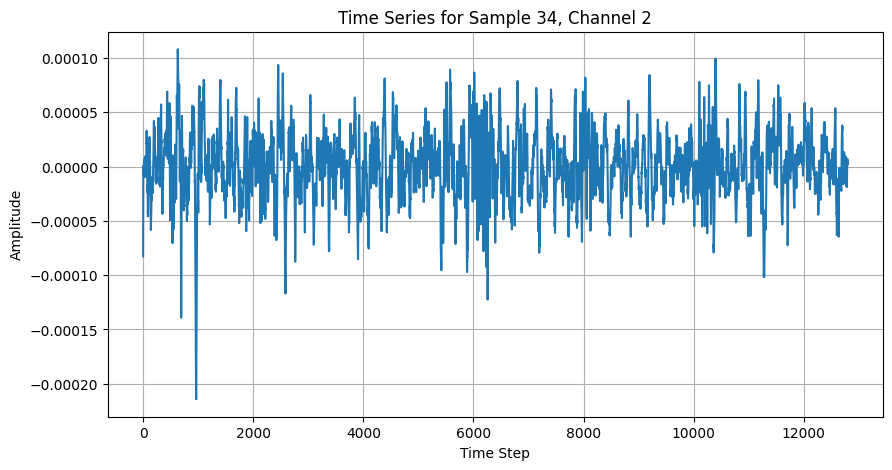

In [ ]:
import matplotlib.pyplot as plt

# 选择要绘制的样本和通道
sample_index = 33  # 选择第一个样本
channel_index = 1  # 选择第一个通道

# 获取时间序列数据
time_series_data = selected_data[sample_index, :, channel_index]  # 选取指定样本和通道
print(time_series_data)
# 绘制时间序列
plt.figure(figsize=(10, 5))
plt.plot(time_series_data)
plt.title(f'Time Series for Sample {sample_index + 1}, Channel {channel_index + 1}')
plt.xlabel('Time Step')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()


# End


For the labels, we have the list of indices of positive examples (seizures), we just need to transform this list into a single vector of labels for each sample.

### Normalize

### **数据正则化（Normalization）方法**
为了使 `seizure_cd.csv` 的数据既保留特征又适合线性动态模型（如 ARIMA、LSTM、Kalman Filter 等），可以采用以下正则化方法：

---

## **1. Min-Max Normalization（最常用）**
**公式**：
\[
X_{\text{norm}} = \frac{X - X_{\min}}{X_{\max} - X_{\min}}
\]
**适用场景**：
- 数据分布范围已知，且没有极端异常值。
- 适合大多数线性模型（如线性回归、SVM）。

**Python 实现**：
```python
import pandas as pd
import numpy as np

# 读取数据
data = pd.read_csv("seizure_cd.csv")

# Min-Max 归一化
normalized_data = (data - data.min()) / (data.max() - data.min())

# 保存归一化后的数据
normalized_data.to_csv("seizure_cd_normalized.csv", index=False)
```

---

## **2. Z-Score Normalization（标准化）**
**公式**：
\[
X_{\text{std}} = \frac{X - \mu}{\sigma}
\]
**适用场景**：
- 数据符合高斯分布（或接近高斯分布）。
- 适合 PCA、神经网络、线性动态模型（如 Kalman Filter）。

**Python 实现**：
```python
# Z-Score 标准化
standardized_data = (data - data.mean()) / data.std()

# 保存标准化后的数据
standardized_data.to_csv("seizure_cd_standardized.csv", index=False)
```

---

## **3. Robust Scaling（抗异常值）**
**公式**：
\[
X_{\text{robust}} = \frac{X - \text{Median}}{\text{IQR}}
\]
**适用场景**：
- 数据有异常值（Outliers）。
- 适合 EEG 信号（可能因噪声导致极端值）。

**Python 实现**：
```python
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
robust_data = scaler.fit_transform(data)

# 转换回 DataFrame
robust_data = pd.DataFrame(robust_data, columns=data.columns)

# 保存
robust_data.to_csv("seizure_cd_robust.csv", index=False)
```

---

## **4. Log Transformation（对数变换）**
**公式**：
\[
X_{\text{log}} = \log(1 + X)
\]
**适用场景**：
- 数据有偏态分布（Skewed Data）。
- 适合 EEG 信号（可能因幅值变化大）。

**Python 实现**：
```python
# 对数变换（避免 log(0) 错误）
log_data = np.log1p(data - data.min() + 1e-10)  # 加极小值防止 log(0)

# 保存
log_data.to_csv("seizure_cd_log.csv", index=False)
```

---

## **5. Power Transformation（Box-Cox / Yeo-Johnson）**
**公式**：
\[
X_{\text{transformed}} = \begin{cases}
\frac{X^\lambda - 1}{\lambda} & \text{if } \lambda \neq 0 \\
\log(X) & \text{if } \lambda = 0
\end{cases}
\]
**适用场景**：
- 数据有非线性特征，需要更接近高斯分布。

**Python 实现**：
```python
from sklearn.preprocessing import PowerTransformer

# Yeo-Johnson（适用于正负值）
transformer = PowerTransformer(method="yeo-johnson")
transformed_data = transformer.fit_transform(data)

# 转换回 DataFrame
transformed_data = pd.DataFrame(transformed_data, columns=data.columns)

# 保存
transformed_data.to_csv("seizure_cd_power_transformed.csv", index=False)
```

---

## **推荐方法**
| 方法 | 适用场景 | 是否适合 EEG 信号 |
|------|----------|------------------|
| **Min-Max** | 数据范围固定，无异常值 | ✅ 适合 |
| **Z-Score** | 数据接近高斯分布 | ✅ 适合 |
| **Robust Scaling** | 数据有噪声/异常值 | ✅ **最佳选择** |
| **Log Transform** | 数据有偏态分布 | ⚠️ 需检查数据 |
| **Power Transform** | 数据非线性 | ⚠️ 需调参 |

### **建议**
1. **先用 Robust Scaling**（EEG 信号常有噪声）。
2. 如果数据分布较均匀，再用 **Z-Score** 或 **Min-Max**。
3. 如果数据有偏态，尝试 **Log Transform** 或 **Box-Cox**。

---

## **最终代码（推荐 Robust Scaling）**
```python
import pandas as pd
from sklearn.preprocessing import RobustScaler

# 读取数据
data = pd.read_csv("seizure_cd.csv")

# Robust Scaling
scaler = RobustScaler()
normalized_data = scaler.fit_transform(data)

# 保存
normalized_data = pd.DataFrame(normalized_data, columns=data.columns)
normalized_data.to_csv("seizure_cd_normalized_robust.csv", index=False)
```

这样处理后的数据：
- **保留了原始特征**（因为 Robust Scaling 不受异常值影响）。
- **适合线性动态模型**（如 LSTM、Kalman Filter、ARIMA）。

## CNN Seizure Classifier

The first task that we will explore is using a convolutional neural network (CNN) to predict whether a time series sample represents a seizure event or not. CNNs are typically used for image classification, and they use 2D convolution because images have 2-dimensional structure. However, our time series is 1-dimensional, so we will use 1D convolution.

Now you might think, isn't our time series data 2-dimensional since there are also channels? Yes, our data is 2-dimensional in the sense that each data sample is a 12,800 x 23 time series. However, the 23 channels in our data are independent of each other, so it would not make sense to convolve _across_ channels. Think of it in another way -- does it matter how the channels are ordered? By constrast, does it matter how the rows or columns in an image are ordered? That is the key difference here.

First we define a few functions we will use to automate the train/test cycle for our CNN model:

In [ ]:
def train_test_split(X, y, train_size=0.8, n_timesteps=12800):
    # compute split index
    split_index = int(X.shape[0] * train_size)

    # extract train set
    X_train = X[:split_index, :n_timesteps]
    y_train = y[:split_index]

    # extract test set
    X_test = X[split_index:, :n_timesteps]
    y_test = y[split_index:]

    return X_train, y_train, X_test, y_test

def create_cnn(X_train, y_train, X_test, y_test):
    # get data dimensions
    n_timesteps = X_train.shape[1]
    n_channels = X_train.shape[2]

    # create model
    model = keras.models.Sequential()
    model.add(keras.layers.Conv1D(filters=64, kernel_size=3, padding='same', activation='relu', input_shape=(n_timesteps, n_channels)))
    model.add(keras.layers.Conv1D(filters=64, kernel_size=3, padding='same', activation='relu'))
    model.add(keras.layers.Dropout(0.5))
    model.add(keras.layers.MaxPooling1D(pool_size=2))
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(100, activation='relu'))
    model.add(keras.layers.Dense(1, activation='sigmoid'))

    # compile model
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    return model

def run_experiment():
    # create train/test data
    X_train, y_train, X_test, y_test = train_test_split(X, y)

    # create model
    model = create_cnn(X_train, y_train, X_test, y_test)

    # print model summary
    model.summary()

    # train model
    history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=True)

    # evaluate model
    score = model.evaluate(X_test, y_test)

    # print test accuracy for test set
    print('test accuracy: %f' % (score[1]))

    # plot the training accuracy
    plt.figure(figsize=(20, 6))
    plt.plot(history.history['acc'])
    plt.plot(history.history['val_acc'])
    plt.title('Training Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='upper left')
    plt.show()

    # plot the training loss
    plt.figure(figsize=(20, 6))
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Training Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='upper left')
    plt.show()

Now we are ready to train and evaluate our CNN. We've encapsulated all of the code into a single function to make it really simple.

In [ ]:
run_experiment()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)                    │ (None, 12800, 64)           │           4,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 12800, 64)           │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 12800, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 6400, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 409600)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 100)                 │      40,960,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40,977,033 (156.31 MB)

 Trainable params: 40,977,033 (156.31 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.7757 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.8465 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.8543 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.8192 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8387 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.8465 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.8348 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.8621 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy:

ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 23
'y' sizes: 24


## LSTM Time Series Forecasting

The second task we will explore is using a long short-term memory (LSTM) model to perform time-series forecasting with our dataset. In other words, given the beginning portion of a time series, can we predict what the next $n$ time steps will be? This kind of application could be very useful to predict a seizure _before_ it happens. Since we now have a CNN model that can predict with high accuracy whether a time series is a seizure event, all we have to do is feed the time series forecast from the LSTM into the CNN classifier. If the LSTM can accurately predict what the next time points will be, and the CNN can accurately predict whether those time points represent a seizure event, then we will be well on our way to predicting seizures before they happen!

For now we will focus on _single-step_ forecasting, where we only predict one time point at a time. In practice we will need to predict many time steps at once in order to be fast enough for real-time applications.

Sources used for reference:
- https://towardsdatascience.com/using-lstms-to-forecast-time-series-4ab688386b1f
- https://github.com/kmsravindra/ML-AI-experiments/blob/master/AI/LSTM-time_series/LSTM%20-%20Sine%20wave%20predictor.ipynb

__NOTE__: The multi-step forecasting code (`n_steps > 1`) does not work yet. So that would be a good place to start if you're looking to work with this project!

In [ ]:
def lstm_create(window_size):
    # create lstm model
    model = keras.models.Sequential()
    model.add(keras.layers.LSTM(window_size, return_sequences=True, input_shape=(window_size, 1)))
    model.add(keras.layers.Dropout(0.5))
    model.add(keras.layers.LSTM(256))
    model.add(keras.layers.Dropout(0.5))
    model.add(keras.layers.Dense(1))
    model.add(keras.layers.Activation("linear"))

    # compile model
    model.compile(loss="mse", optimizer="adam")

    return model

def lstm_train(model, X_train, y_train):
    t1 = time.time()
    model.fit(X_train, y_train, batch_size=512, epochs=3, validation_split=0.1, verbose=False)
    t2 = time.time()

    print('train time: %f s' % (t2 - t1))

def lstm_predict(model, X_test, y_test, scaler, n_steps):
    # compute single-step prediction
    if n_steps == 1:
        y_pred = model.predict(X_test)

    # or compute multi-step prediction (note: does not work yet)
    else:
        y_pred = np.empty(n_steps)
        X_window = X_test[0:1, :]

        for i in range(n_steps):
            # compute single-step prediction
            y_pred_i = model.predict(X_window)
            y_pred_i = y_pred_i.reshape(1, 1, 1)

            # append single-step prediction to multi-step prediction
            y_pred[i] = y_pred_i[0, 0, 0]

            # update moving window
            X_window = np.concatenate([X_window[:, 1:, :], y_pred_i], axis=1)

    # get de-normalized ground truth, model predictions
    y_test = scaler.inverse_transform(y_test)
    y_pred = scaler.inverse_transform(y_pred)

    # report mean-squared error
    print('mse: %g' % (sklearn.metrics.mean_squared_error(y_test, y_pred)))

    return y_pred, y_test

def lstm_forecast(x, window_size=100, train_size=0.8, n_steps=1):
    # normalize input data to the range [-1, 1]
    scaler = sklearn.preprocessing.MinMaxScaler(feature_range=(-1, 1))
    x = scaler.fit_transform(x)
    x = pd.DataFrame(x)

    # augment input data with time-shifted copies
    x_orig = x.copy()

    for i in range(window_size):
        x = pd.concat([x, x_orig.shift(-(i+1))], axis=1)

    # remove rows with missing data
    x.dropna(axis=0, inplace=True)

    # convert input data to numpy array
    x = x.values
    x = x.reshape(x.shape[0], x.shape[1], 1)

    # create train/test sets
    split_index = int(x.shape[0] * train_size)

    train = x[:split_index, :]
    test = x[split_index:, :]

    train = sklearn.utils.shuffle(train)

    X_train = train[:, :-1]
    y_train = train[:, -1]
    X_test = test[:, :-1]
    y_test = test[:, -1]

    # create lstm model
    model = lstm_create(window_size)

    # print model summary
    # model.summary()

    # train lstm model
    lstm_train(model, X_train, y_train)

    # compute forecast
    y_pred, y_test = lstm_predict(model, X_test, y_test, scaler, n_steps)

    return y_pred, y_test

def lstm_plot(y_test, y_pred, channel_name):
    s_rate = 256
    t = np.arange(len(y_test)) / s_rate

    plt.figure(figsize=(20, 6))
    plt.plot(t, y_test, label='Actual')
    plt.plot(t, y_pred, label='Predicted')
    plt.legend()
    plt.xlabel('Time (t) [s]')
    plt.ylabel('Voltage (V) [V]')
    plt.title('EEG Forecast for %s' % (channel_name))
    plt.show()

In [ ]:
# get channel csv filenames
csv_files = glob.glob('seizure.*.csv')

# initialize output arrays
channels = []
y_pred = []
y_test = []

# perform time series forecast for each channel
for filename in csv_files:
    # get channel name
    channel_name = filename.split('.')[-2]

    print(channel_name)

    # read channel dataframe
    df_channel = pd.read_csv(filename)

    # perform forecasting for a random sample
    column = random.choice(df_channel.columns)

    # extract channel k, sample i
    x_ki = pd.DataFrame(df_channel[column])

    # perform time series forecasting
    y_pred_ki, y_test_ki = lstm_forecast(x_ki)

    # append results
    channels.append(channel_name)
    y_pred.append(y_pred_ki)
    y_test.append(y_test_ki)

In [ ]:
# plot results
for k in range(len(y_pred)):
    lstm_plot(y_test[k], y_pred[k], channels[k])